
# Analises - Knowledge Distillation de Classificadores de Imagens

**MO434 - Aprendizado Profundo para Visao Computacional**

---

## Objetivo do Projeto

Treinar um modelo **student** leve que imita as representacoes internas de um modelo **teacher**
pre-treinado (VGG, ResNet, ConvNeXt), de forma que o student consiga classificar imagens com
muito menos parametros e operacoes (GFLOPs) do que o teacher.

## As 3 Fases

```
Fase 1 - Treinar o CLASSIFICADOR do teacher (encoder congelado)
Fase 2 - Treinar ENCODER + PREDITOR do student (imitacao de features do teacher)
Fase 3 - Testar student com o MESMO classificador treinado na Fase 1
```

## As 5 Perguntas de Pesquisa

| # | Pergunta | O que implementar |
|---|----------|------------------|
| Q1 | Qual teacher transfere melhor? | Comparar VGG-16, ResNet-50, ConvNeXt-S |
| Q2 | Student deve prever pre-GAP ou post-GAP? | Duas variantes de preditor |
| Q3 | Qual a melhor arquitetura do student? | Plain CNN vs Depthwise vs Mini-ResNet |
| Q4 | Qual a melhor funcao de perda? | Ablacao de alpha em L = alpha*MSE + (1-alpha)*CE |
| Q5 | O que aprender da literatura de KD? | Implementar RKD e comparar com baseline |

---

## Datasets Utilizados

| Dataset | Classes | Imagens | Tamanho | Papel no projeto |
|---------|---------|---------|---------|-----------------|
| **Flowers-102** | 102 | ~8K | ~330MB | **Principal (Q1-Q4)**: fine-grained, 102 classes exige representacoes ricas |
| **Oxford-IIIT-Pet** | 37 | ~7K | ~800MB | **Validacao cruzada**: confirma que resultados generalizam |

**Por que Flowers-102 para Q1?** Com 102 classes de flores visualmente similares,
o teacher precisa de representacoes discriminativas de alta qualidade. A diferenca
entre VGG, ResNet e ConvNeXt fica mais evidente do que em datasets com classes
bem separadas.

**Por que Oxford-IIIT-Pet como segundo dataset?** 37 racas de caes e gatos e
um problema diferente (granularidade fina, menos classes), confirmando que
os resultados do student nao dependem de um unico dominio.


## Imports


In [ ]:
# instalacao das dependencias do projeto
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
# !pip install fvcore torchmetrics matplotlib seaborn pandas tqdm

In [ ]:
## importacoes gerais do projeto
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from copy import deepcopy
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets, models

## classes e utilitarios do projeto (definidos em kd_run.py)
from kd_run import (
    set_seed, Timer,
    ImageTransforms, DatasetManager,
    TeacherWrapper,
    PlainCNNEncoder, DepthwiseCNNEncoder, MiniResNetEncoder,
    PreditorPostGAP, PreditorPreGAP, StudentModel,
    PerdaKD, PerdaRKD,
    Trainer, Evaluator,
    plotar_curvas, plotar_comparacao_mse_rkd, plotar_graficos_analise,
)

## verificacao de dispositivo (gpu ou cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"dispositivo em uso: {device}")
if torch.cuda.is_available():
    print(f"gpu: {torch.cuda.get_device_name(0)}")
    print(f"memoria gpu: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


dispositivo em uso: cuda
gpu: Tesla T4
memoria gpu: 15.6 GB


---
## Seção 1 - Preparação dos Datasets

O projeto pede que tenha pelos menos 2 datasets

### Pre-processamento para modelos pre-treinados no ImageNet

Todos os backbones : VGG, ResNet, ConvNeXt, foram treinados com imagens normalizadas
com a **media e desvio padrao do ImageNet**.

```
media  = [0.485, 0.456, 0.406]
desvio = [0.229, 0.224, 0.225]
```

Além disso, os modelos escolhidos esperam entradas de **224x224 pixels**.


In [9]:

with Timer("definicao das transformacoes de imagem"):
    # parametros de normalizacao do imagenet (obrigatorio para modelos pre-treinados)
    # todos os valores estao encapsulados em ImageTransforms (kd_utils.py)
    IMAGENET_MEAN = ImageTransforms.IMAGENET_MEAN
    IMAGENET_STD  = ImageTransforms.IMAGENET_STD

    # transformacoes padrao (validacao e teste, sem augmentacao)
    transform_val = ImageTransforms.get_val_transform()

    # transformacoes com augmentacao (somente para o conjunto de treino)
    # a augmentacao aumenta a diversidade sem coletar novos dados
    transform_train = ImageTransforms.get_train_transform()

print("transformacoes definidas com sucesso!")


[timer] definicao das transformacoes de imagem        -> 0.00 s
transformacoes definidas com sucesso!


In [ ]:
# DatasetManager cuida do download, splits e DataLoaders (kd_utils.py)

# dataset 1: flowers-102 - 102 classes de flores, ~8.000 imagens
# splits oficiais: train (1020 imgs), val (1020 imgs), test (6149 imgs)
# ideal para comparar teachers (Q1): fine-grained, ConvNeXt tende a se sair melhor

# dataset 2: oxford-iiit-pet - 37 classes (racas de caes e gatos), ~7.000 imagens
# testa transferencia em classificacao de granularidade fina com menos dados

with Timer("carregamento dos datasets (flowers102 + oxford-pets)"):
    dataset_manager = DatasetManager(data_root='./data', batch_size=32, num_workers=2)
    DATASETS = dataset_manager.load_all()

# aliases para acesso direto aos loaders
loader_f102_train = DATASETS['flowers102']['train']
loader_f102_val   = DATASETS['flowers102']['val']
loader_f102_test  = DATASETS['flowers102']['test']

loader_pets_train = DATASETS['pets']['train']
loader_pets_val   = DATASETS['pets']['val']
loader_pets_test  = DATASETS['pets']['test']


100%|██████████| 345M/345M [00:16<00:00, 21.2MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.79MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 48.0MB/s]


flowers-102 -> treino: 1,020 | val: 1,020 | teste: 6,149


100%|██████████| 792M/792M [00:33<00:00, 23.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.4MB/s]


oxford-pets -> treino: 2,944 | val: 736 | teste: 3,669
[timer] carregamento dos datasets (flowers102 + oxford-pets) -> 9 min 4.5 s


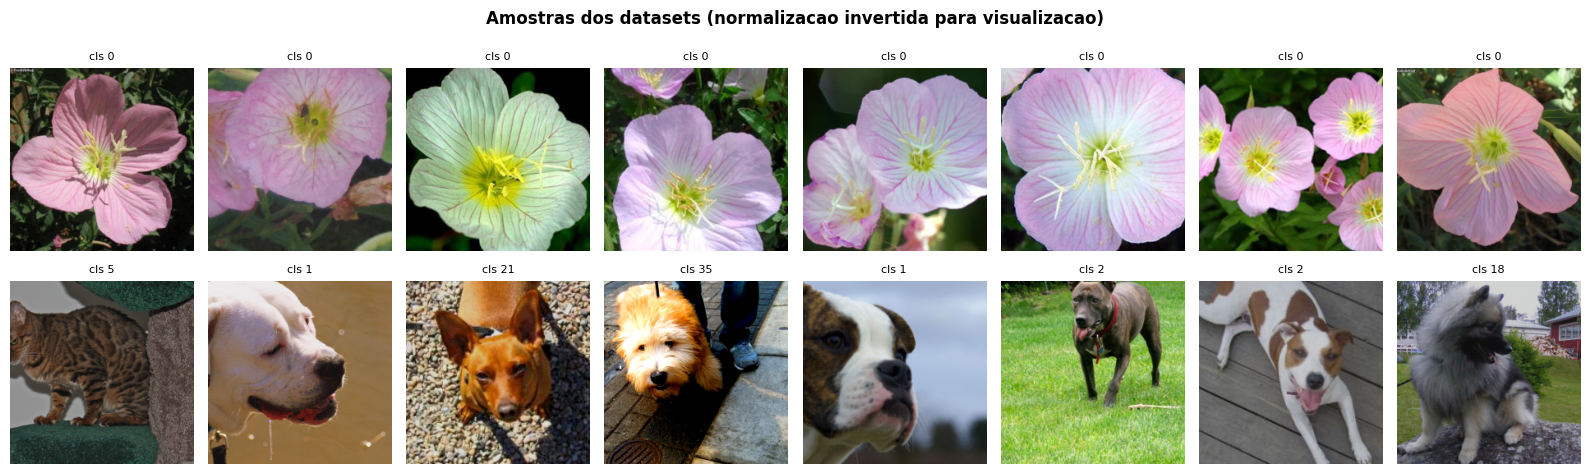

In [ ]:
# visualizacao: amostras de imagens dos dois datasets
# dataset_manager.visualizar_amostras inverte a normalizacao do ImageNet
# para exibir as imagens corretamente
dataset_manager.visualizar_amostras(n_imgs=8)


---
## Seção 2 - Modelo Teacher

### Conceito: O papel do Teacher no KD

O **teacher** é um backbone pre-treinado no ImageNet cujo encoder esta **congelado**
(pesos nunca atualizados). Apenas o classificador final e treinado no novo dataset.

### Estrutura de um backbone moderno

```
Imagem [B, 3, 224, 224]
    |
[ENCODER CONGELADO]   <- pesos ImageNet, nunca atualizados
    |
Feature map pre-GAP: [B, C, 7, 7]
    |
Global Average Pooling (GAP)
    |
Vetor post-GAP: [B, C]
    |
[CLASSIFICADOR TREINAVEL]   <- so esta parte e treinada na Fase 1
    |
Logits: [B, n_classes]
```

### Teachers comparados no projeto

| Teacher | Parametros | GFLOPs | dim post-GAP | Caracteristica |
|---------|------------|--------|--------------|----------------|
| VGG-16 | 138M | 15.5 | 512 | Classico, sem skip connections |
| ResNet-50 | 25M | 4.1 | 2048 | Baseline mais estudado em KD |
| ConvNeXt-Small | 50M | 8.7 | 768 | Moderno, melhor accuracy |


In [ ]:
# teacherWrapper definido em kd_utils.py
# encapsula encoder + gap + classificador de forma modular
# permite extrair pre-gap [B, C, 7, 7] e post-gap [B, C] de forma uniforme

# teste rapido de shapes para cada teacher
print("verificando shapes dos teachers...")
with Timer("verificacao de shapes dos teachers"):
    with torch.no_grad():
        dummy = torch.randn(2, 3, 224, 224)
        for name in ['vgg16', 'resnet50', 'convnext_small']:
            t      = TeacherWrapper(name, n_classes=100)
            t.eval()
            pre    = t.get_pre_gap(dummy)
            post   = t.get_post_gap(dummy)
            logits = t(dummy)
            params = sum(p.numel() for p in t.parameters()) / 1e6
            print(f"  {name:16s} | pre-gap: {str(pre.shape):22s} | post-gap: {str(post.shape):14s} | params: {params:.1f}M")


verificando shapes dos teachers...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 146MB/s]


  vgg16            | pre-gap: torch.Size([2, 512, 7, 7]) | post-gap: torch.Size([2, 512]) | params: 14.8M
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


  resnet50         | pre-gap: torch.Size([2, 2048, 7, 7]) | post-gap: torch.Size([2, 2048]) | params: 23.7M
Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:01<00:00, 126MB/s]


  convnext_small   | pre-gap: torch.Size([2, 768, 7, 7]) | post-gap: torch.Size([2, 768]) | params: 49.5M
[timer] verificacao de shapes dos teachers            -> 13.88 s


---
## Seção 3 - Fase 1: treinar o classificador do teacher

### O que fazemos aqui?

O encoder do teacher ja sabe extrair features (pre-treinado no ImageNet).
Mas o classificador original foi treinado para 1000 classes do ImageNet, nao
para as classes do nosso dataset.

Na Fase 1 tenho que:
1. Congelar o encoder (nenhum gradiente passa por ele)
2. Trocar a ultima camada do classificador por uma nova com `n_classes` saidas
3. Treinar **apenas o classificador** com Cross-Entropy Loss

### Função de perda: Cross-Entropy

$$L_{CE} = -\frac{1}{N}\sum_{i=1}^{N} \log(\hat{y}_{i, c_i})$$

onde $\hat{y}_{i, c_i}$ e a probabilidade predita para a classe correta $c_i$.


In [ ]:
# inicializar o Trainer e o Evaluator
# todos os loops de treino (fase 1 e fase 2) estao encapsulados em Trainer (kd_utils.py)
# a avaliacao final (fase 3) e as metricas de eficiencia estao em Evaluator (kd_utils.py)

SEED = 42
trainer   = Trainer(device=device, seed=SEED)
evaluator = Evaluator(device=device)

print("trainer e evaluator inicializados.")

semente fixada: 42 (random, numpy, torch, cuda)
trainer e evaluator inicializados.



 teacher: RESNET50 | dataset: flowers102
encoder resnet50 congelado.
  parametros treinaveis: 208,998


  epoca   1 | loss_tr=4.3633 acc_tr=0.137 | loss_vl=3.8032 acc_vl=0.614 | gap=-0.476


  epoca   5 | loss_tr=1.5464 acc_tr=0.971 | loss_vl=1.9070 acc_vl=0.845 | gap=+0.127


  epoca  10 | loss_tr=0.7848 acc_tr=0.994 | loss_vl=1.3928 acc_vl=0.870 | gap=+0.124


  epoca  15 | loss_tr=0.6753 acc_tr=0.994 | loss_vl=1.2807 acc_vl=0.874 | gap=+0.120
  melhor acc validacao: 0.8739 (epoca 15)
  acuracia TESTE: 0.8463
  classificador salvo em checkpoints/


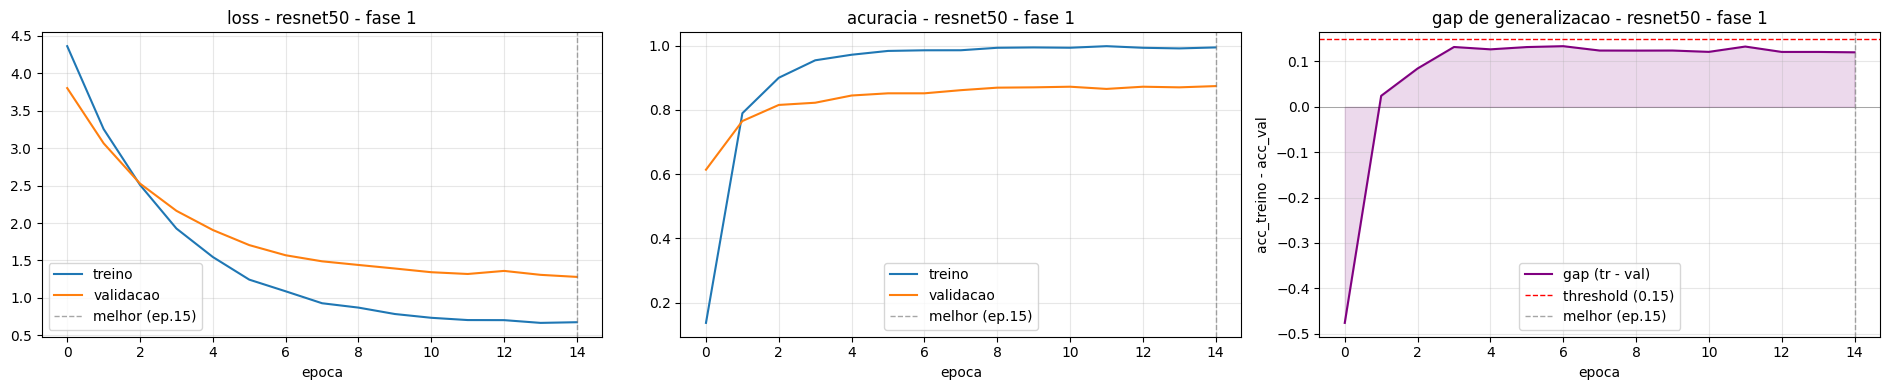


 teacher: VGG16 | dataset: flowers102
encoder vgg16 congelado.
  parametros treinaveis: 52,326


  epoca   1 | loss_tr=4.4915 acc_tr=0.042 | loss_vl=4.0429 acc_vl=0.224 | gap=-0.182


  epoca   5 | loss_tr=2.5041 acc_tr=0.845 | loss_vl=2.5404 acc_vl=0.740 | gap=+0.105


  epoca  10 | loss_tr=1.6962 acc_tr=0.929 | loss_vl=1.9596 acc_vl=0.793 | gap=+0.136


  epoca  15 | loss_tr=1.5381 acc_tr=0.933 | loss_vl=1.8717 acc_vl=0.802 | gap=+0.131
  melhor acc validacao: 0.8025 (epoca 14)
  acuracia TESTE: 0.7636
  classificador salvo em checkpoints/


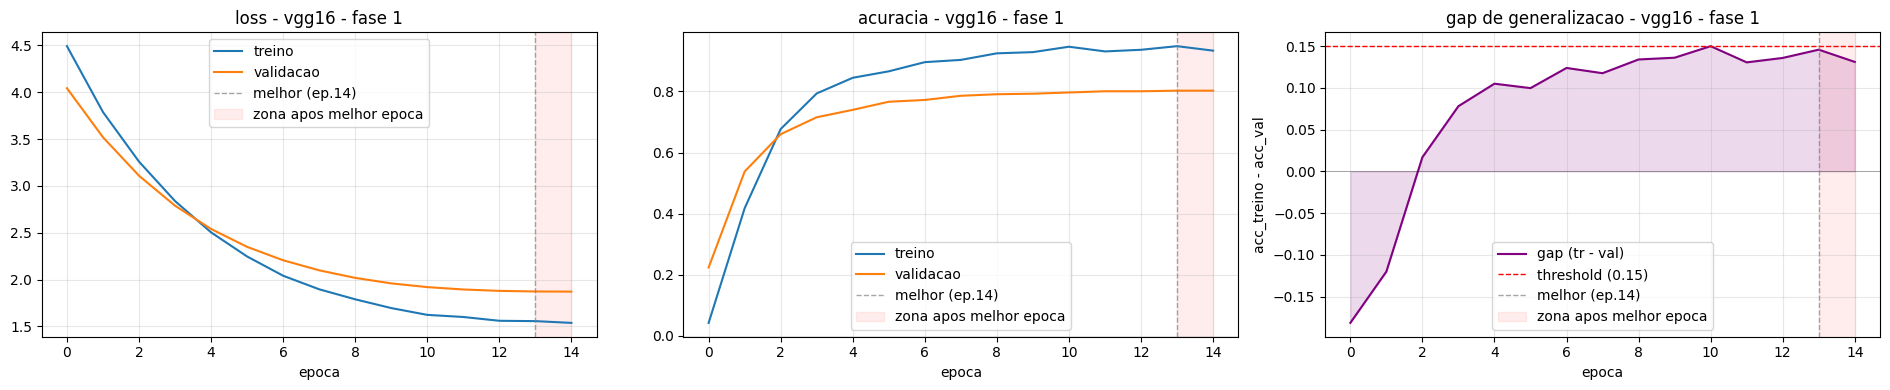


 teacher: CONVNEXT_SMALL | dataset: flowers102
encoder convnext_small congelado.
  parametros treinaveis: 79,974


  epoca   1 | loss_tr=4.2866 acc_tr=0.123 | loss_vl=3.1090 acc_vl=0.467 | gap=-0.344


  epoca   5 | loss_tr=0.9711 acc_tr=0.907 | loss_vl=0.9655 acc_vl=0.856 | gap=+0.051


  epoca  10 | loss_tr=0.4390 acc_tr=0.973 | loss_vl=0.6526 acc_vl=0.897 | gap=+0.075


  epoca  15 | loss_tr=0.3755 acc_tr=0.972 | loss_vl=0.6125 acc_vl=0.912 | gap=+0.061
  melhor acc validacao: 0.9138 (epoca 12)
  acuracia TESTE: 0.8710
  classificador salvo em checkpoints/


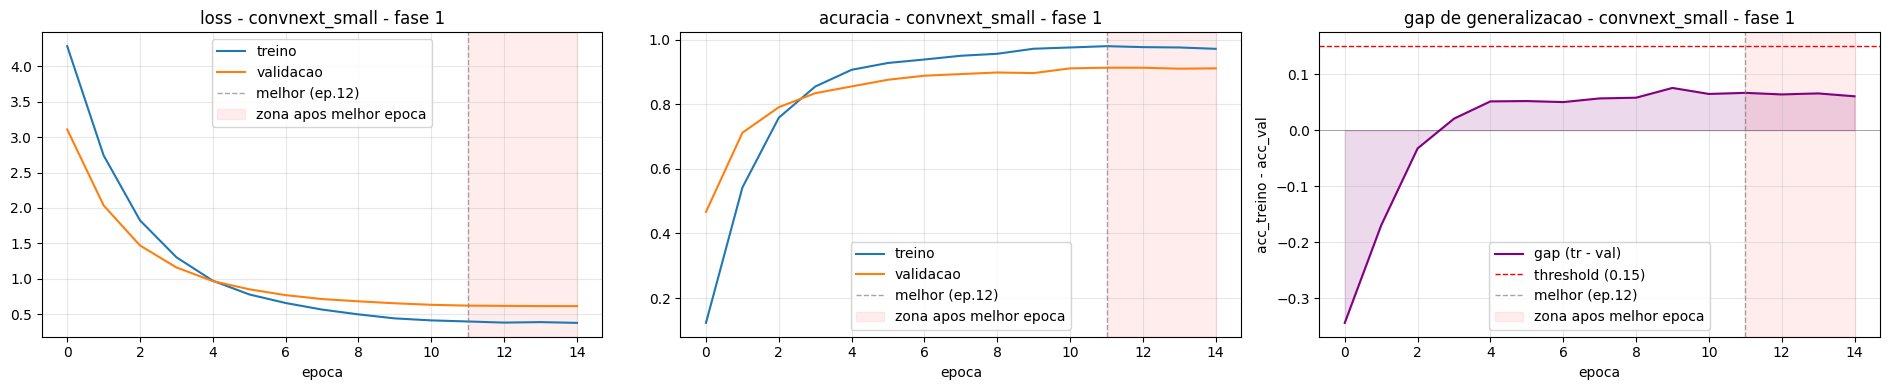

In [ ]:
# fase 1: treinar classificador de cada teacher

DATASET_ESCOLHIDO = 'flowers102'  # troque por 'pets' para o segundo dataset
N_CLASSES         = DATASETS[DATASET_ESCOLHIDO]['n_classes']
EPOCHS_FASE1      = 15            # 15 epocas sao suficientes: o encoder ja e bom
LR_FASE1          = 1e-3

# dicionario para guardar resultados de todos os teachers
resultados_fase1 = {}

# loop pelos tres teachers
for nome_teacher in ['resnet50', 'vgg16', 'convnext_small']:
    print(f"\n{'='*60}")
    print(f" teacher: {nome_teacher.upper()} | dataset: {DATASET_ESCOLHIDO}")
    print(f"{'='*60}")

    # cria o teacher e congela o encoder (passo obrigatorio)
    teacher = TeacherWrapper(nome_teacher, n_classes=N_CLASSES).to(device)
    teacher.freeze_encoder()

    # apenas os parametros do classificador sao atualizados
    params_treinaveis = [p for p in teacher.parameters() if p.requires_grad]
    print(f"  parametros treinaveis: {sum(p.numel() for p in params_treinaveis):,}")

    optimizer = optim.Adam(params_treinaveis, lr=LR_FASE1, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FASE1)

    historico = trainer.treinar_fase1(
        model        = teacher,
        loader_train = DATASETS[DATASET_ESCOLHIDO]['train'],
        loader_val   = DATASETS[DATASET_ESCOLHIDO]['val'],
        optimizer    = optimizer,
        scheduler    = scheduler,
        n_epochs     = EPOCHS_FASE1,
        descricao    = nome_teacher,
    )

    # avalia no conjunto de teste
    acc_teste = trainer.avaliar_loader(teacher, DATASETS[DATASET_ESCOLHIDO]['test'])
    print(f"  acuracia TESTE: {acc_teste:.4f}")

    resultados_fase1[nome_teacher] = {
        'teacher_obj': teacher,
        'historico':   historico,
        'acc_teste':   acc_teste,
    }

    # salva o classificador (sera reutilizado na fase 3)
    os.makedirs("checkpoints", exist_ok=True)
    torch.save(teacher.classifier.state_dict(),
               f"checkpoints/classifier_{nome_teacher}_{DATASET_ESCOLHIDO}.pth")
    print(f"  classificador salvo em checkpoints/")
    plotar_curvas(historico, titulo=f"{nome_teacher} - fase 1")


In [15]:
# tabela de comparacao: Q1 - qual teacher transfere melhor?

print("\nQ1 - Comparacao de Teachers (Fase 1)\n")
linhas = []
for nome, dados in resultados_fase1.items():
    linhas.append({'teacher': nome, 'acc_teste': dados['acc_teste']})

df_q1 = pd.DataFrame(linhas).sort_values('acc_teste', ascending=False)
df_q1['params_M'] = df_q1['teacher'].map({'vgg16': 138, 'resnet50': 25, 'convnext_small': 50})
df_q1['gflops']   = df_q1['teacher'].map({'vgg16': 15.5, 'resnet50': 4.1, 'convnext_small': 8.7})
print(df_q1.to_string(index=False))
print()
print("-> observacao esperada: accuracy nao e proporcional ao tamanho do teacher")
print("-> capacidade de transferencia depende da qualidade das representacoes")



Q1 - Comparacao de Teachers (Fase 1)

       teacher  acc_teste  params_M  gflops
convnext_small   0.870952        50     8.7
      resnet50   0.846341        25     4.1
         vgg16   0.763601       138    15.5

-> observacao esperada: accuracy nao e proporcional ao tamanho do teacher
-> capacidade de transferencia depende da qualidade das representacoes


---
## Seção 4 - Arquitetura do Student

O student deve ser consideravelmente mais leve que o teacher:
- Menos de 10% dos GFLOPs do teacher
- Menos de 20% dos parametros do teacher

### Duas partes do student

```
Imagem
  |
[ENCODER DO STUDENT]
(CNN leve que aprende features proprias)
  |
Features: [B, C_s, H_s, W_s]
  |
[PREDITOR DO STUDENT]
(mapeia features student -> espaco do teacher)
  |
Predicao: [B, C_teacher]
```

### Q2 - Tipos de preditor

| Tipo | Alvo | Preditor | Vantagem |
|------|------|----------|----------|
| **post-GAP** | vetor [B, C_t] | MLP (denso) | simples, dimensao baixa |
| **pre-GAP** | mapa [B, C_t, 7, 7] | Conv + pool | preserva localizacao espacial |

### Q3 - Três variantes de encoder

| Variante | Descricao | Custo |
|----------|-----------|-------|
| PlainCNN | Conv-BN-ReLU empilhados | baseline |
| DepthwiseCNN | Convolucao depthwise-separavel (MobileNet) | ~8x menos params |
| MiniResNet | Conv + skip connections | melhor fluxo de gradiente |


In [ ]:
# encoders do student definidos em kd_utils.py

# verificacao de shapes e parametros
print("shapes e parametros dos encoders do student:\n")
dummy = torch.randn(2, 3, 224, 224)
STUDENT_CHANNELS = (32, 64, 128, 256)

for nome, Encoder in [('PlainCNN', PlainCNNEncoder),
                       ('Depthwise', DepthwiseCNNEncoder),
                       ('MiniResNet', MiniResNetEncoder)]:
    enc = Encoder(STUDENT_CHANNELS)
    with torch.no_grad():
        out = enc(dummy)
    params = sum(p.numel() for p in enc.parameters()) / 1e6
    print(f"  {nome:12s} | saida: {str(out.shape):24s} | params: {params:.2f}M")


shapes e parametros dos encoders do student:

  PlainCNN     | saida: torch.Size([2, 256, 14, 14]) | params: 0.39M
  Depthwise    | saida: torch.Size([2, 256, 14, 14]) | params: 0.05M
  MiniResNet   | saida: torch.Size([2, 256, 14, 14]) | params: 1.94M


In [ ]:
# preditores definidos em kd_utils.py

# verificacao de shapes dos dois tipos de preditor (Q2)
print("shapes dos preditores:\n")
dummy_feat = torch.randn(2, 256, 14, 14)
for nome_t, dim_t in [('resnet50', 2048), ('vgg16', 512), ('convnext_small', 768)]:
    pred_post = PreditorPostGAP(256, dim_t)
    pred_pre  = PreditorPreGAP(256, dim_t)
    with torch.no_grad():
        out_post = pred_post(dummy_feat)
        out_pre  = pred_pre(dummy_feat)
    print(f"  teacher={nome_t:15s} | post-gap: {str(out_post.shape):16s} | pre-gap: {str(out_pre.shape)}")


shapes dos preditores:

  teacher=resnet50        | post-gap: torch.Size([2, 2048]) | pre-gap: torch.Size([2, 2048, 7, 7])
  teacher=vgg16           | post-gap: torch.Size([2, 512]) | pre-gap: torch.Size([2, 512, 7, 7])
  teacher=convnext_small  | post-gap: torch.Size([2, 768]) | pre-gap: torch.Size([2, 768, 7, 7])


---
## Seção 5 - Funcoes de Perda (Q4 e Q5)

### Q4 - Combinação MSE + Cross-Entropy

A perda total combina dois objetivos:

$$L_{total} = \alpha \cdot L_{MSE} + (1 - \alpha) \cdot L_{CE}$$

- **$L_{MSE}$**: alinha features do student com features do teacher
- **$L_{CE}$**: mantém previsoes alinhadas com rotulos verdadeiros
- **$\alpha$**: hiperparametro para balancear os dois objetivos

| alpha | Significado |
|-------|-------------|
| 1.0 | so MSE (destilacao pura, sem rotulos) |
| 0.0 | so CE (ignora teacher) |
| 0.7 | ponto de partida recomendado |

### Q5 - Relational Knowledge Distillation (RKD)

Ao inves de alinhar **valores absolutos** de features, o RKD alinha as
**relações entre amostras** (distancias par-a-par):

> "Amostras similares no espaco do teacher devem ser similares no espaco do student"
> (Park et al., CVPR 2019)


In [ ]:
# funcoes de perda definidas em kd_utils.py
# PerdaKD  - L = alpha * MSE + (1 - alpha) * CE (Q4)
# PerdaRKD - alinha distancias par-a-par ao inves de valores absolutos (Q5)

# teste rapido das funcoes de perda
print("testando funcoes de perda:")
pred_s = torch.randn(8, 2048)
feat_t = torch.randn(8, 2048)
logits = torch.randn(8, 100)
labels = torch.randint(0, 100, (8,))

perda_kd  = PerdaKD(alpha=0.7)
perda_rkd = PerdaRKD()

l_total, l_mse, l_ce = perda_kd(pred_s, feat_t, logits, labels)
l_rkd = perda_rkd(pred_s, feat_t)

print(f"  perda kd  (alpha=0.7): total={l_total:.4f} | mse={l_mse:.4f} | ce={l_ce:.4f}")
print(f"  perda rkd:             {l_rkd:.4f}")


testando funcoes de perda:
  perda kd  (alpha=0.7): total=2.7166 | mse=1.9730 | ce=4.4517
  perda rkd:             0.0010


---
## Seção 6 - Fase 2: treinar o student por destilação

### Como funciona a Fase 2?

O teacher esta completamente congelado. O student aprende a imitar
as features do teacher atraves do gradiente da perda de destilação.

```
Imagem -> [TEACHER ENCODER, congelado] -> features_teacher (alvo, sem gradiente)
Imagem -> [STUDENT ENCODER, treina]    -> features_student_raw
       -> [PREDITOR, treina]           -> pred_features
                                             |
                                  MSE(pred_features, features_teacher)
                                  + CE(classifier(pred_features), labels)
```

### Ponto critico: torch.no_grad() no teacher
Ao extrair features do teacher, não posso deixar os gradientes fluirem pelo encoder.
Usar with torch.no_grad() para economizar memória


In [ ]:
# experimento principal fase 2: responde Q1, Q2, Q3 e Q4

EPOCHS_FASE2  = 30      # aumentar para 50 no experimento final
LR_FASE2      = 1e-3
DATASET_FASE2 = 'flowers102'

# configuracoes do experimento (teacher, encoder, modo_target, alpha)
CONFIGS_EXPERIMENTO = [
    # Q3 - comparar tres encoders com mesmo teacher e alpha
    ('resnet50', PlainCNNEncoder,     'post_gap', 0.7),
    ('resnet50', DepthwiseCNNEncoder, 'post_gap', 0.7),
    ('resnet50', MiniResNetEncoder,   'post_gap', 0.7),
    # Q2 - comparar pre-gap vs post-gap com mesmo encoder
    ('resnet50', PlainCNNEncoder,     'pre_gap',  0.7),
    # Q1 - comparar outros teachers
    ('vgg16',          PlainCNNEncoder, 'post_gap', 0.7),
    ('convnext_small', PlainCNNEncoder, 'post_gap', 0.7),
    # Q4 - ablacao de alpha (so MSE, so CE, combinacoes)
    ('resnet50', PlainCNNEncoder, 'post_gap', 1.0),
    ('resnet50', PlainCNNEncoder, 'post_gap', 0.5),
    ('resnet50', PlainCNNEncoder, 'post_gap', 0.0),
]

resultados_fase2 = []

for nome_teacher, EncoderCls, modo_target, alpha in CONFIGS_EXPERIMENTO:
    descricao = f"{nome_teacher[:3]}_{EncoderCls.__name__[:5]}_{modo_target[:3]}_a{alpha}"
    print(f"\n{'─'*62}")
    print(f" teacher={nome_teacher} | encoder={EncoderCls.__name__}")
    print(f" target={modo_target} | alpha={alpha}")
    print(f"{'─'*62}")

    # recupera teacher ja treinado na fase 1
    teacher = resultados_fase1[nome_teacher]['teacher_obj'].to(device)

    # constroi o student
    encoder  = EncoderCls(STUDENT_CHANNELS)
    dim_t    = teacher.feat_dim
    preditor = (PreditorPostGAP(encoder.out_dim, dim_t)
                if modo_target == 'post_gap'
                else PreditorPreGAP(encoder.out_dim, dim_t))
    student = StudentModel(encoder, preditor).to(device)

    # relatorio de eficiencia (Q3)
    params_s = sum(p.numel() for p in student.parameters()) / 1e6
    params_t = sum(p.numel() for p in teacher.parameters()) / 1e6
    print(f"  params student: {params_s:.2f}M | teacher: {params_t:.2f}M ({params_s/params_t*100:.1f}%)")

    # treina por destilacao via trainer.treinar_fase2 (kd_utils.py)
    perda_fn = PerdaKD(alpha=alpha)
    historico, melhor_acc = trainer.treinar_fase2(
        student      = student,
        teacher      = teacher,
        loader_train = DATASETS[DATASET_FASE2]['train'],
        loader_val   = DATASETS[DATASET_FASE2]['val'],
        perda_fn     = perda_fn,
        n_epochs     = EPOCHS_FASE2,
        lr           = LR_FASE2,
        modo_target  = modo_target,
        descricao    = descricao,
    )

    resultados_fase2.append({
        'descricao':   descricao,
        'teacher':     nome_teacher,
        'encoder':     EncoderCls.__name__,
        'modo_target': modo_target,
        'alpha':       alpha,
        'melhor_acc':  melhor_acc,
        'params_M':    params_s,
        'historico':   historico,
        'student_obj': student,
    })

    os.makedirs("checkpoints", exist_ok=True)
    torch.save(student.state_dict(), f"checkpoints/student_{descricao}.pth")



──────────────────────────────────────────────────────────────
 teacher=resnet50 | encoder=PlainCNNEncoder
 target=post_gap | alpha=0.7
──────────────────────────────────────────────────────────────
  params student: 1.57M | teacher: 23.72M (6.6%)


  ep.  1 | mse=0.0391 | acc_tr=0.011 acc_vl=0.010 | gap=+0.001


  ep.  5 | mse=0.0354 | acc_tr=0.078 acc_vl=0.085 | gap=-0.007


  ep. 10 | mse=0.0343 | acc_tr=0.166 acc_vl=0.157 | gap=+0.009


  ep. 15 | mse=0.0339 | acc_tr=0.235 acc_vl=0.188 | gap=+0.047


...

  ep. 25 | mse=0.0328 | acc_tr=0.319 acc_vl=0.295 | gap=+0.024


  ep. 30 | mse=0.0323 | acc_tr=0.361 acc_vl=0.316 | gap=+0.045
  melhor acc validacao: 0.3168 (epoca 28)

──────────────────────────────────────────────────────────────
 teacher=resnet50 | encoder=PlainCNNEncoder
 target=post_gap | alpha=0.0
──────────────────────────────────────────────────────────────
  params student: 1.57M | teacher: 23.72M (6.6%)


  ep.  1 | mse=0.0598 | acc_tr=0.001 acc_vl=0.004 | gap=-0.003


  ep.  5 | mse=0.0599 | acc_tr=0.004 acc_vl=0.003 | gap=+0.001


  early stopping na epoca 6 (sem melhora por 5 epocas). melhor: epoca 1
  melhor acc validacao: 0.0039 (epoca 1)


---
## Seção 7 - Q5: Comparacao com a Literatura (RKD)


  treinando: MSE_baseline
    melhor acc: 0.2241
  treinando: RKD
    melhor acc: 0.0156


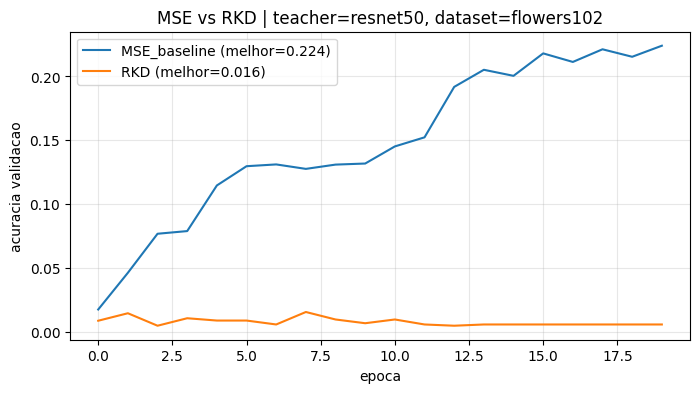

In [ ]:
# comparacao mse-baseline vs rkd (Q5)
# trainer.comparar_mse_vs_rkd encapsula o loop de comparacao (kd_utils.py)

# MSE forca o student a copiar os valores absolutos das features.
# RKD alinha as relacoes entre amostras, invariante a escala.
# util quando o student tem capacidade menor (capacity mismatch).

teacher_q5     = resultados_fase1['resnet50']['teacher_obj'].to(device)
resultados_q5  = trainer.comparar_mse_vs_rkd(
    teacher      = teacher_q5,
    datasets     = DATASETS,
    teacher_nome = 'resnet50',
    dataset_nome = 'flowers102',
    n_epochs     = 20,
)
plotar_comparacao_mse_rkd(resultados_q5, 'resnet50', 'flowers102')


---
## Seção 8 - Fase 3: Avaliação Final

### O teste definitivo

Na Fase 3, o **classificador da Fase 1** (congelado) e usado para avaliar
o student no conjunto de **teste**. Isso mede diretamente se o student
aprendeu a produzir features no mesmo espaco do teacher.

Se o student aprendeu bem as representacoes, o classificador do teacher
conseguira classificar as predicoes do student com alta acuracia, mesmo
nunca tendo visto as features do student durante o treinamento.


In [ ]:
# evaluator.avaliar_fase3 usa o classificador do teacher para avaliar o student
# o classificador nunca viu as features do student: transferencia real de conhecimento

print("Avaliacao Fase 3 - todos os experimentos\n")
print(f"{'descricao':45s} {'acc_val':>8s} {'acc_test':>9s} {'params_M':>9s}")
print("─" * 76)

for exp in resultados_fase2:
    teacher = resultados_fase1[exp['teacher']]['teacher_obj'].to(device)
    acc_test, acc_top5 = evaluator.avaliar_fase3(
        exp['student_obj'], teacher,
        DATASETS[DATASET_FASE2]['test'],
        exp['modo_target']
    )
    exp['acc_test'] = acc_test
    top5_str = f" (top5={acc_top5:.3f})" if acc_top5 else ""
    print(f"  {exp['descricao']:43s} {exp['melhor_acc']:>8.4f} {acc_test:>9.4f} {exp['params_M']:>9.2f}M{top5_str}")


Avaliacao Fase 3 - todos os experimentos

descricao                                      acc_val  acc_test  params_M
────────────────────────────────────────────────────────────────────────────
  res_Plain_pos_a0.7                            0.3153    0.2495      1.57M (top5=0.525)
  res_Depth_pos_a0.7                            0.2818    0.2343      1.23M (top5=0.525)
  res_MiniR_pos_a0.7                            0.2596    0.2154      3.12M (top5=0.500)
  res_Plain_pre_a0.7                            0.1014    0.0997      0.92M (top5=0.355)
  vgg_Plain_pos_a0.7                            0.2606    0.1944      0.78M (top5=0.483)
  con_Plain_pos_a0.7                            0.2006    0.1681      0.91M (top5=0.419)
  res_Plain_pos_a1.0                            0.2882    0.2366      1.57M (top5=0.531)
  res_Plain_pos_a0.5                            0.3168    0.2542      1.57M (top5=0.536)
  res_Plain_pos_a0.0                            0.0039    0.0050      1.57M (top5=0.053)


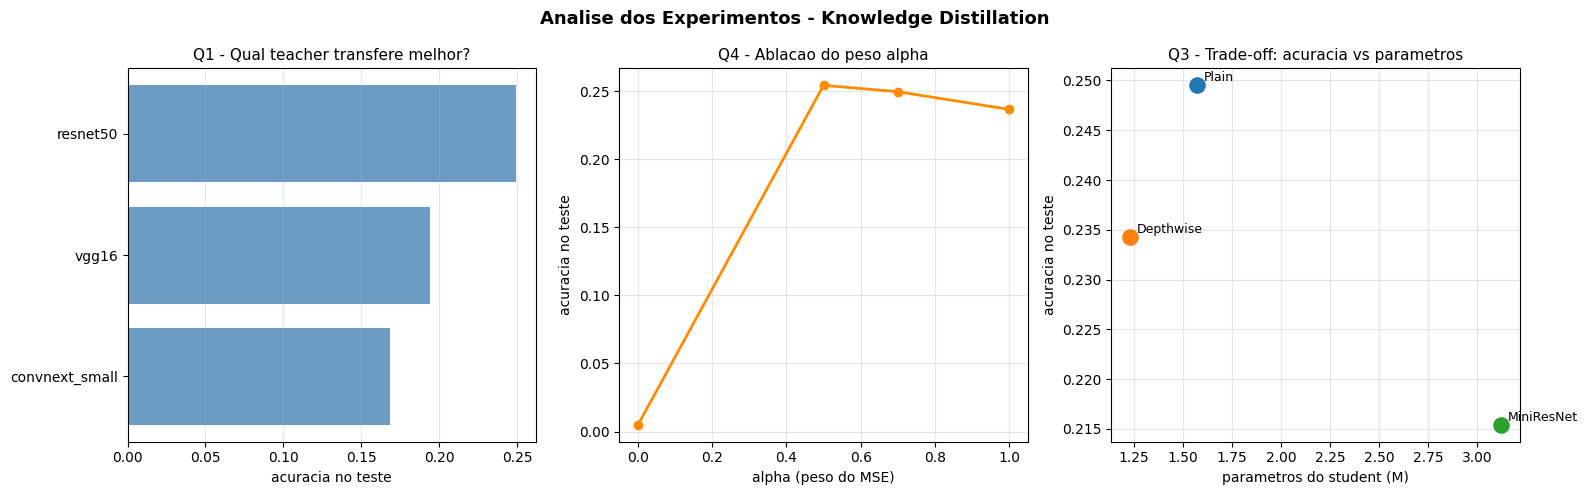

In [ ]:
# graficos de analise final (plotar_graficos_analise em kd_utils.py)
# responde Q1, Q3 e Q4 visualmente

df_resultados = pd.DataFrame([
    {
        'teacher':  r['teacher'],
        'encoder':  r['encoder'],
        'target':   r['modo_target'],
        'alpha':    r['alpha'],
        'acc_val':  r['melhor_acc'],
        'acc_test': r.get('acc_test', 0),
        'params_M': r['params_M'],
    }
    for r in resultados_fase2
])

plotar_graficos_analise(df_resultados)


In [ ]:
# tabela final com respostas para cada questao
# df_resultados foi construido na celula de graficos acima

# Q1
print("=" * 55)
print(" Q1 - QUAL TEACHER TRANSFERE MELHOR?")
print("=" * 55)
q1 = df_resultados[
    (df_resultados['encoder'] == 'PlainCNNEncoder') &
    (df_resultados['target']  == 'post_gap') &
    (df_resultados['alpha']   == 0.7)
][['teacher', 'acc_test']].sort_values('acc_test', ascending=False)
print(q1.to_string(index=False))

# Q2
print("\n" + "=" * 55)
print(" Q2 - PRE-GAP VS POST-GAP?")
print("=" * 55)
q2 = df_resultados[
    (df_resultados['teacher'] == 'resnet50') &
    (df_resultados['encoder'] == 'PlainCNNEncoder') &
    (df_resultados['alpha']   == 0.7)
][['target', 'acc_test']].sort_values('acc_test', ascending=False)
print(q2.to_string(index=False))

# Q3
print("\n" + "=" * 55)
print(" Q3 - MELHOR ARQUITETURA DO STUDENT?")
print("=" * 55)
q3 = df_resultados[
    (df_resultados['teacher'] == 'resnet50') &
    (df_resultados['target']  == 'post_gap') &
    (df_resultados['alpha']   == 0.7)
][['encoder', 'acc_test', 'params_M']].sort_values('acc_test', ascending=False)
print(q3.to_string(index=False))

# Q4
print("\n" + "=" * 55)
print(" Q4 - MELHOR FUNCAO DE PERDA?")
print("=" * 55)
q4 = df_resultados[
    (df_resultados['teacher'] == 'resnet50') &
    (df_resultados['encoder'] == 'PlainCNNEncoder') &
    (df_resultados['target']  == 'post_gap')
][['alpha', 'acc_test']].sort_values('alpha')
print(q4.to_string(index=False))

 Q1 - QUAL TEACHER TRANSFERE MELHOR?
       teacher  acc_test
      resnet50  0.249514
         vgg16  0.194430
convnext_small  0.168135

 Q2 - PRE-GAP VS POST-GAP?
  target  acc_test
post_gap  0.249514
 pre_gap  0.099741

 Q3 - MELHOR ARQUITETURA DO STUDENT?
            encoder  acc_test  params_M
    PlainCNNEncoder  0.249514  1.571104
DepthwiseCNNEncoder  0.234294  1.229504
  MiniResNetEncoder  0.215415  3.121184

 Q4 - MELHOR FUNCAO DE PERDA?
 alpha  acc_test
   0.0  0.005019
   0.5  0.254210
   0.7  0.249514
   1.0  0.236561


---
## Seção 9 - Métricas de Eficiência


In [ ]:
# calculo de gflops e parametros
# evaluator.relatorio_eficiencia usa fvcore para contar operacoes (kd_utils.py)
# se fvcore nao estiver instalado, exibe apenas parametros

teacher_ref = resultados_fase1['resnet50']['teacher_obj']
evaluator.relatorio_eficiencia(teacher_ref, resultados_fase2)


Eficiencia Computacional

modelo                           gflops   params_M      reducao
─────────────────────────────────────────────────────────────────
  resnet50 (teacher)                n/d       23.7M        (ref)
  PlainCNNEncoder                   n/d       1.57M         6.6%
  DepthwiseCNNEncoder               n/d       1.23M         5.2%
  MiniResNetEncoder                 n/d       3.12M        13.2%
  PlainCNNEncoder                   n/d       0.78M         3.3%
  PlainCNNEncoder                   n/d       0.91M         3.9%


---
## Seção 10 - Checklist e próximos passos

### O que voce ja implementou

- Dois datasets 
- Três teachers (VGG-16, ResNet-50, ConvNeXt-Small) 
- Fase 1: treino do classificador com encoder congelado 
- Três variantes de encoder do student (Plain, Depthwise, MiniResNet)
- Dois preditores (post-GAP e pre-GAP)
- Fase 2: loop de destilacao com MSE + CE
- Exploração de alpha (Q4)
- Perda RKD para Q5
- Fase 3: avaliação com classificador fixo
- Tabelas e gráficos de analise

### Melhorias para o experimento final

```python
# aumentar epocas (recomendado para resultados finais)
EPOCHS_FASE1 = 20
EPOCHS_FASE2 = 50

# repetir para o segundo dataset
for dataset_nome in ['cifar100', 'stl10']:
    for nome_teacher in ['resnet50', 'vgg16', 'convnext_small']:
        ...

# mixed precision para treinar mais rapido na GPU
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()
with autocast():
    pred  = student(imgs)
    perda = perda_fn(...)
scaler.scale(perda).backward()
scaler.step(optimizer)
scaler.update()
```

### Referências

1. Hinton et al. (2015) - Distilling the Knowledge in a Neural Network [arXiv:1503.02531]
2. Romero et al. (2015) - FitNets: Hints for Thin Deep Nets [ICLR 2015]
3. Zagoruyko & Komodakis (2017) - Paying More Attention to Attention [ICLR 2017]
4. Park et al. (2019) - Relational Knowledge Distillation [CVPR 2019]
5. Cooper et al. (2025) - Logit-Based Losses Limit Feature KD [OpenReview]
6. Goodfellow, Bengio & Courville (2016) - Deep Learning [MIT Press]
